In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import lstsq
from sklearn.model_selection import train_test_split
import cvxpy as cp

In [18]:
df_data = pd.read_parquet("training_data/initial_dataset.parquet")
df_train_detached = pd.read_parquet(
    "training_data/data_detached_with_weather.parquet")
type(df_data)
type(df_train_detached)
df_train_detached
unique_ids = df_train_detached["Property_ID"].unique()
id_use = unique_ids[3]
df_house = pd.read_csv('training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual", "HP_Size_kW"
]

# calculate min capacity in home 
cp_air = 1.005  #kJ/kgK
rho_air = 1.225  # kg/m^3
kj_to_kWh = 1 / 3600
df_house["Volume"] = df_house["Total_Floor_Area"] * df_house["Floor_Height"]
df_house["Min Capacity"] = df_house["Volume"] * cp_air * rho_air * kj_to_kWh

df_home_values = df_house[df_house["Property_ID"].isin(unique_ids)]

summary = df_home_values[["Property_ID", "Min Capacity"]].drop_duplicates()
print(summary)

home_dict = df_home_values.set_index("Property_ID").to_dict(orient="index")

trained_params = pd.DataFrame(index=["Floor Area", "No_Storeys", "Wall_Type",
                                     "C", "R_a", "w_s", "w_w", "w",
                                     "Q_hat", "Q_sc", "rmse_dTi",
                                     "rmse_q_hp"])

df_single = df_train_detached[df_train_detached["Property_ID"] == id_use].copy()
df_single = df_single.set_index('Timestamp')

#time range for indexing only
t_start = pd.to_datetime("2022 01 01 00:00:00")
t_mid_end = pd.to_datetime("2022 5 31 23:59:59")
t_mid_start = pd.to_datetime("2022 08 31 00:00:00")
t_end = pd.to_datetime("2022 12 31 23:59:59")
df_index = df_single[df_single.index >= t_start]
df_index = df_index[df_index.index <= t_end]
df_index = df_index[
    (df_index.index <= t_mid_end) | (df_index.index >= t_mid_start)]

# Create time index for q_hat arrays
time_index = df_index.index[:-1]
df_q_id = pd.DataFrame(index=time_index)

# ---- initialize and clean data ---------
wall = home_dict[id_use]["Wall_Type"]
storeys = home_dict[id_use]["No_Storeys"]
floor_area = home_dict[id_use]["Total_Floor_Area"]

df_single = df_train_detached[
    df_train_detached["Property_ID"] == id_use].copy()

#re-adjust Heat Pump Diff and add temp differences
df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
    "Heat_Pump_Energy_Output"].diff()
df_single["Internal_Temperature_Diff"] = df_single[
    "Internal_Air_Temperature"].diff()
df_single["Internal_Ambient_Temperature_Diff"] = \
    (df_single["External_Air_Temperature"] -
     df_single["Internal_Air_Temperature"])

# 1. Drop columns with almost all missing data (e.g., more than 90% missing)
threshold = 0.90 * len(df_single)
df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
#print("Columns dropped due to high missing values:")
#print(df_single.columns.difference(df_single_cleaned.columns).tolist())

df_single = df_single_cleaned

#print("\nColumns remaining after dropping highly missing columns:")
#print(df_single.columns.tolist())

df_single = df_single.set_index('Timestamp')
df_single = df_single.sort_index()

# Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
numeric_cols = df_single.select_dtypes(include=['number']).columns
df_single_numeric_interpolated = df_single[numeric_cols].interpolate(
    method='time', limit=4, limit_direction='both')

df_single_interpolated = df_single.copy()
df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

# After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
initial_rows = len(df_single_interpolated)
df_single_processed = df_single_interpolated.dropna()
rows_dropped_after_interpolation = initial_rows - len(df_single_processed)

#print(f"\nNumber of rows dropped after handling NA values (missing for >
# 2 hours): {rows_dropped_after_interpolation}")

q_hp = (df_single_processed["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy())
# -----EXTRACT SUMMER DATA -------# 
df_heating_single = df_single_processed.copy()
#df_heating_single = [df_single_processed["External_Air_Temperature"]<=18]

# Time range
t_start = pd.to_datetime("2022-6-01 00:00:00")
t_end = pd.to_datetime("2022-8-30 23:59:00")
df_DHW = df_heating_single[
    (df_heating_single.index >= t_start) & (
            df_heating_single.index <= t_end)
    ].copy()

df_DHW.drop("Property_ID", axis=1, inplace=True)
df_DHW.drop("half-hour", axis=1, inplace=True)
df_DHW.drop("Date", axis=1, inplace=True)
df_DHW.drop("has_data", axis=1, inplace=True)

i = 24

df_numeric = df_DHW.select_dtypes(include='number')

# Resample and compute mean
df_resampled = df_numeric.resample(f'{i}h').mean()

#df_DHW_only = df_resampled[
    #df_resampled["Heat_Pump_Energy_Output_Diff"] <= 1]
df_DHW_only = df_resampled[
    df_resampled["External_Air_Temperature"] >= 15]

DHW_sum = []
DHW_sum = df_DHW_only["Heat_Pump_Energy_Output_Diff"].sum() * 24

df_spc_only = df_resampled[
    df_resampled["Heat_Pump_Energy_Output_Diff"] > 0.15]
SPC_sum = df_spc_only["Heat_Pump_Energy_Output_Diff"].sum() * 24

     Property_ID  Min Capacity
76       EOH3196      0.086941
318      EOH0413      0.094570
585      EOH2329      0.099645
736      EOH1637      0.088733
1149     EOH3154      0.116411
1156     EOH2675      0.124696
1569     EOH1485      0.115696
1692     EOH0546      0.088239
2066     EOH0279      0.138493
2381     EOH1703      0.074688


In [20]:
df_DHW_only

,Circulation_Pump_Energy_Consumed,Heat_Pump_Energy_Output,Whole_System_Energy_Consumed,External_Air_Temperature,Heat_Pump_Heating_Flow_Temperature,Heat_Pump_Return_Temperature,Internal_Air_Temperature,Hot_Water_Flow_Temperature,Immersion_Heater_Energy_Consumed,Heat_Pump_Energy_Output_Diff,Temperature,FeelsLike,Humidity,Dew,Precipitation,SolarRadiation,SolarEnergy,Windspeed,Internal_Temperature_Diff,Internal_Ambient_Temperature_Diff
Timestamp,,,,,,,,,,,,,,,,,,,,
2022-06-10,69.455000,17275.644792,6924.340729,15.012292,28.127500,27.630417,19.562292,46.613125,139.762000,0.113729,14.788542,14.788542,75.764479,10.289583,0.018417,301.083333,1.075000,27.107292,0.021458,-4.550000
2022-06-15,69.487000,17313.798771,6938.590812,15.087292,28.346146,27.016250,20.316875,43.323777,139.762000,0.137562,14.350000,14.250000,71.044896,8.694792,0.000000,290.958333,1.041667,7.136458,0.058750,-5.229583
2022-06-16,69.487000,17319.807875,6942.542833,16.277917,30.162917,28.232083,21.974375,45.593723,141.320813,0.078250,15.645833,15.562500,73.346771,10.653125,0.000625,232.458333,0.833333,10.852083,0.003958,-5.696458
2022-06-17,69.487000,17325.327958,6945.229229,15.363542,30.377708,29.418333,21.598333,43.024313,141.678000,0.169187,15.338542,15.338542,70.295417,9.877083,0.053542,189.666667,0.683333,18.618750,-0.020000,-6.234792
2022-06-22,69.487000,17361.923417,6959.174687,16.440625,28.841875,28.342292,21.816875,45.665938,141.678000,0.141229,16.187500,16.187500,77.356354,11.931250,0.000000,308.958333,1.104167,12.772917,0.027292,-5.376250
2022-06-23,69.487000,17367.471729,6962.376042,17.485208,30.314583,28.985625,22.545833,47.669896,142.650312,0.094000,17.086458,17.086458,75.473438,12.350000,0.194635,256.750000,0.916667,11.609375,0.020833,-5.060625
2022-06-24,69.487000,17372.532500,6964.682729,16.720833,30.706250,29.618542,23.398333,47.891250,142.878000,0.117583,16.470833,16.470833,85.054479,13.759375,0.409156,203.833333,0.725000,8.088542,-0.014375,-6.677500
2022-06-29,69.487000,17399.679500,6976.080063,17.047341,29.171042,27.333958,19.572500,45.274375,142.878000,0.076292,13.727083,13.727083,86.204479,11.398958,0.233667,190.791667,0.691667,12.305208,0.022292,-2.525159
2022-06-30,69.487000,17402.860688,6979.660375,17.005537,30.167708,27.889583,20.843542,46.766771,144.760167,0.051917,13.680208,13.667708,80.504688,10.168750,0.070333,236.083333,0.850000,7.811458,0.033542,-3.838005


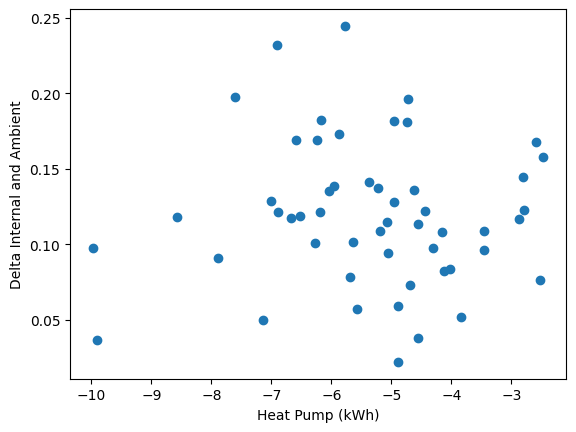

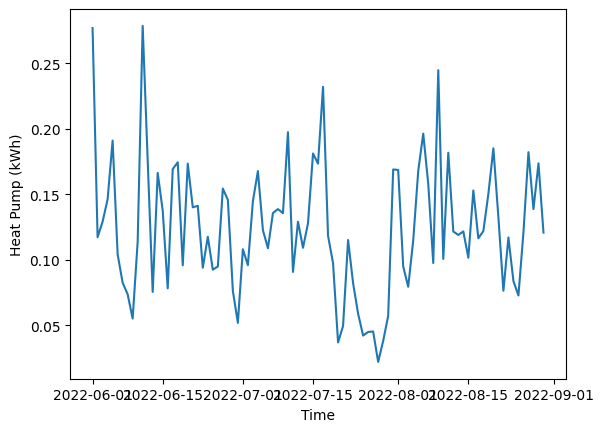

In [19]:
plt.scatter(df_DHW_only["Internal_Ambient_Temperature_Diff"],
            df_DHW_only["Heat_Pump_Energy_Output_Diff"])
plt.xlabel("Heat Pump (kWh)")
plt.ylabel("Delta Internal and Ambient")
plt.show()

plt.plot(df_resampled["Heat_Pump_Energy_Output_Diff"])
plt.xlabel("Time")
plt.ylabel("Heat Pump (kWh)")
plt.show()

In [ ]:
q = -df_resampled["Heat_Pump_Energy_Output_Diff"].to_numpy()
delta_t = df_resampled["Internal_Ambient_Temperature_Diff"].to_numpy()

 = lstsq(q, delta_t)


In [5]:
unique_ids = df_train_detached["Property_ID"].unique()

df_house = pd.read_csv('training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual","HP_Size_kW",
    "HP_Installed", "House_SAP"
]

df_house_train = {}
for id_use in unique_ids:
    df_house_train[id_use] = df_house[df_house["Property_ID"] == id_use]

In [6]:
t_start = pd.to_datetime("2022 01 01 00:00:00")
t_mid_end = pd.to_datetime("2022 5 31 23:59:59")
t_mid_start = pd.to_datetime("2022 08 31 00:00:00")
t_end = pd.to_datetime("2022 12 31 23:59:59")
df_heating_annual = df_heating_single[df_heating_single.index >= t_start]
df_heating_annual = df_heating_annual[df_heating_annual.index <= t_end]
df_heating_annual = df_heating_annual[
    (df_heating_annual.index <= t_mid_end) | (df_heating_annual
                                              .index >= t_mid_start)]

q_hp_2 = (df_heating_annual["Heat_Pump_Energy_Output_Diff"].iloc[:-1]
        .reset_index(drop=True).to_numpy())

In [7]:
t_start_y = pd.to_datetime("2022-1-01 00:00:00")
t_end_y = pd.to_datetime("2022-12-31 23:59:00")
df_year = df_heating_single[
    (df_heating_single.index >= t_start_y) & (
            df_heating_single.index <= t_end_y)
    ].copy()

Q_sc = df_year["Heat_Pump_Energy_Output_Diff"].sum()


Q_DHW_estimate = df_house_train[id_use].MCS_DHWAnnual.to_numpy()
q_max = df_house_train[id_use].HP_Size_kW.to_numpy()
print(Q_DHW_estimate)
print(DHW_sum)
print(q_hp.sum())
print(q_hp_2.sum())
print(Q_sc)
print(Q_sc - Q_DHW_estimate - SPC_sum + DHW_sum)
print(q_hp_2.sum() - Q_DHW_estimate - SPC_sum + DHW_sum)
print(np.sum(q_hp_2) - Q_DHW_estimate - SPC_sum + DHW_sum)

[4075.]
271.52700000000004
25037.828999999998
6809.590000000002
7352.644000000002
[3432.9625]
[2889.9085]
[2889.9085]


In [8]:
print(Q_DHW_estimate)

[4075.]
